#### Imagine backend with OpenAI client

Copyright (c) 2025 Qualcomm Innovation Center, Inc. All rights reserved.<br>
SPDX-License-Identifier: BSD-3-Clause-Clear


##### Import the required library packages

In [22]:
from openai import OpenAI
import base64
from IPython.display import Image,Audio

In [23]:
endpoint = "https://cloudai.cirrascale.com/apis/v2" # Imagine endpoint url
api_key = "YOUR_IMAGINE_API_KEY" # Imagine api key 


client = OpenAI(base_url=endpoint, api_key=api_key)

##### Model Type : Chat

In [24]:
prompt = "What are healthy fruits" # provide input prompt
model = "Llama-3.1-8B" # model name

In [25]:
completion = client.chat.completions.create(
  model=model,
  messages=[
    {"role": "system", "content": prompt}
  ]
)
print(completion.choices[0].message.content)


Here's a comprehensive list of healthy fruits that are rich in essential nutrients, vitamins, and minerals:

**Berries**

1. Blueberries: High in antioxidants, fiber, and vitamins C and K.
2. Strawberries: Rich in vitamin C, potassium, and fiber.
3. Raspberries: High in fiber, vitamin C, and manganese.
4. Cranberries: May help prevent urinary tract infections and support heart health.
5. Blackberries: Rich in antioxidants, fiber, and


##### Streaming in small chunks in case of longer response

In [26]:
stream = client.chat.completions.create(
    model=model,
    messages=[{"role": "system", "content": prompt}],
    stream=True,
)
for chunk in stream:
    if chunk.choices[0].delta.content is not None:
        print(chunk.choices[0].delta.content, end="")

Here's a comprehensive list of healthy fruits that are rich in essential nutrients, vitamins, and minerals:

**Berries**

1. Blueberries: High in antioxidants, fiber, and vitamins C and K.
 vitamin C, potassium, and fiber.
3. Raspberries: High in fiber, vitamin C, and manganese.
4. Cranberries: May help prevent urinary tract infections and support heart health.
5. Blackberries: Rich in antioxidants, fiber, and

##### Model Type : Embedding

In [27]:
model_name = "BAAI/bge-large-en-v1.5" # model name
input_text = ["Have a great day ahead"] # List of input texts to be used for embedding

In [28]:
response = client.embeddings.create(
    input=input_text,
    model=model_name
)
# print output embedding vector
print(response.data[0].embedding)

[0.005702972412109375, 0.0274505615234375, -0.036407470703125, 0.003664016723632813, -0.0283966064453125, -0.039947509765625, 0.03704833984375, 0.052032470703125, 0.044921875, 0.00707244873046875, 0.030609130859375, 0.027130126953125, 0.01318359375, -0.01486968994140625, 0.01026153564453125, -0.05694580078125, -0.034271240234375, -0.023834228515625, -0.01032257080078125, 0.047882080078125, -0.0300140380859375, 0.04071044921875, -0.0667724609375, -0.02154541015625, 0.00688934326171875, 0.0467529296875, -0.004840850830078125, -0.0024051666259765625, 0.062744140625, 0.06689453125, -0.046905517578125, -0.02301025390625, 0.0264739990234375, -0.033294677734375, 0.00556182861328125, -0.0293426513671875, 0.048583984375, -0.02984619140625, 0.0195159912109375, -0.0295562744140625, -0.0121612548828125, -0.01383209228515625, 0.0469970703125, -0.0286407470703125, -0.0635986328125, -0.042083740234375, -0.03192138671875, -0.035125732421875, 0.027862548828125, -0.04815673828125, -0.01396942138671875, 

##### Model Type : Text to Image

In [29]:
prompt = "Dog running on green grass" # provide prompt here
num_images = 1 # number of images to be generated
model="stabilityai/sdxl-turbo" # model name to be used for image generation

In [30]:
response = client.images.generate(
    model=model,
    prompt=prompt,
    n=num_images,
)


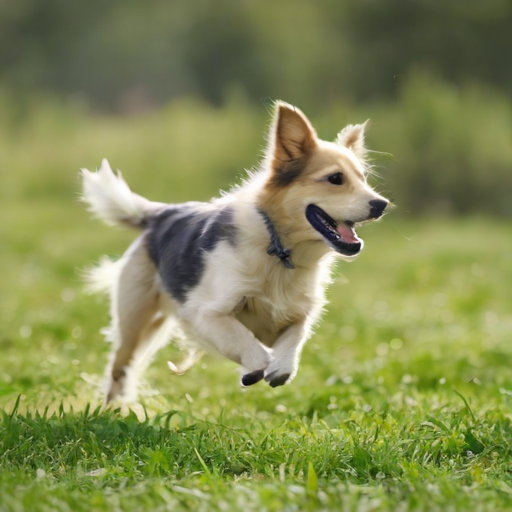

In [31]:
# Display generated image
image_data=base64.decodebytes(response.data[0].b64_json.encode())
Image(image_data)